In [33]:
# Import data manipulation libraries
import pandas as pd
import numpy as np 

# Import visualisation libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import BayesianRidge
from sklearn.cluster import KMeans

import shap 

# Import datetime library
from datetime import datetime
import time

In [3]:
# Load the dataset
df = pd.read_csv('adverts.csv')

In [4]:
# Output the first 5 observations
df.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [5]:
# Sample Data
df.sample(5)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
172486,202010275484495,78470.0,11,Red,MINI,Clubman,USED,2011.0,4895,Estate,False,Diesel
169664,202009254194605,42369.0,15,White,Citroen,C1,USED,2015.0,5249,Hatchback,False,Petrol
127475,202010275485146,85000.0,59,Blue,Fiat,Grande Punto,USED,2009.0,1395,Hatchback,False,Petrol
216919,202007161314685,50.0,20,Grey,Mercedes-Benz,G Class,USED,2020.0,164950,SUV,False,Petrol
47275,202004068872687,10.0,NaN,Grey,SEAT,Ateca,NEW,NaN,29950,SUV,False,Petrol


In [6]:
# Print out dataframe information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  str    
 3   standard_colour        396627 non-null  str    
 4   standard_make          402005 non-null  str    
 5   standard_model         402005 non-null  str    
 6   vehicle_condition      402005 non-null  str    
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  str    
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  str    
dtypes: bool(1), float64(2), int64(2), str(7)
memory usage: 34.1 MB


In [7]:
# Load and sample the dataset
# Load the dataset
df = pd.read_csv('adverts.csv')

# Sample date for quick analysis
df = df.sample(frac=0.2, random_state=99).reset_index(drop=True)

In [8]:
# 1. Data Preprocessing

# Copy the sampled dataframe to avoid modifying the original
df_aml = df.copy()

# Define a function to derive the registration year from the 'reg_code'
def reg_code_to_year(reg_code):
    try:
        code = int(float(reg_code))
        if 51 <= code <= 99: return 2000 + (code - 50)
        elif 0 < code <= 50: return 2000 + code
        else: return np.nan
    except (ValueError, TypeError):
        return np.nan

# Impute year or registration with derived year using reg_code_to_year function 
df_aml['derived_year'] = df_aml['reg_code'].apply(reg_code_to_year)
df_aml['year_of_registration'] = df_aml['year_of_registration'].fillna(df_aml['derived_year']) if 'year_of_registration' in df_aml.columns else df_aml.get('year_of_registration')
df_aml['vehicle_age'] = datetime.now().year - pd.to_numeric(df_aml.get('year_of_registration', pd.Series()), errors='coerce')

# Log-transform the target variable
df_aml['log_price'] = np.log1p(df_aml['price'])

# Drop irrelevant columns
cols_to_drop = ['public_reference', 'reg_code', 'year_of_registration', 'derived_year']
df_aml.drop(columns=[c for c in cols_to_drop if c in df_aml.columns], inplace=True, errors='ignore')

# Drop missing target rows and duplicates
if df_aml['log_price'].isnull().any():
    df_aml.dropna(subset=['log_price'], inplace=True)
df_aml.drop_duplicates(inplace=True)

# Create missingness indicators
for c in df_aml.columns:
    if df_aml[c].isna().any():
        df_aml[f'{c}_missing'] = df_aml[c].isna().astype(int)

# Define features (X) and target (y)
cols_to_exclude = ['price', 'log_price']
X = df_aml.drop(columns=cols_to_exclude, errors='ignore')
y = df_aml['log_price']

# First split: split the dataset into temp (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# Second split: split the 80% temp into train and val (75% of temp = 60% overall train, 25% of temp = 20% overall val)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=99)

# Copies to avoid SettingWithCopyWarning
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()

# Identify numeric and categorical columns for imputation and encoding
num_cols_to_impute = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Imputation (median for numerical and mode for categorical)
imputer_num = SimpleImputer(strategy='median')
X_train[num_cols_to_impute] = imputer_num.fit_transform(X_train[num_cols_to_impute])
X_val[num_cols_to_impute] = imputer_num.transform(X_val[num_cols_to_impute]) 
X_test[num_cols_to_impute] = imputer_num.transform(X_test[num_cols_to_impute])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_val[cat_cols] = imputer_cat.transform(X_val[cat_cols]) 
X_test[cat_cols] = imputer_cat.transform(X_test[cat_cols])

# Outlier clipping 
for c in num_cols_to_impute:
    lo, hi = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(lower=lo, upper=hi)
    X_val[c] = X_val[c].clip(lower=lo, upper=hi) 
    X_test[c] = X_test[c].clip(lower=lo, upper=hi)

# Separate categorical columns based on cardinality 
low_card_cols, high_card_cols = [], []
for c in cat_cols:
    if X_train[c].nunique() <= 20: 
        low_card_cols.append(c)
    else: 
        high_card_cols.append(c)

# Handle rare categories and apply frequency encoding to low cardinality columns
for c in low_card_cols:
    freqs = X_train[c].value_counts(normalize=True)
    rares = freqs[freqs < 0.01].index
    
    # Replace rares
    X_train[c] = X_train[c].replace(list(rares), 'Other')
    X_val[c] = X_val[c].replace(list(rares), 'Other')
    X_test[c] = X_test[c].replace(list(rares), 'Other')
    
    # Frequency encoding
    freq_map = X_train[c].value_counts(normalize=True)
    X_train[f'{c}_freq'] = X_train[c].map(freq_map)
    X_val[f'{c}_freq'] = X_val[c].map(freq_map).fillna(0) 
    X_test[f'{c}_freq'] = X_test[c].map(freq_map).fillna(0)

# Apply target encoding to high cardinality columns
if high_card_cols:
    target_encoder = TargetEncoder(target_type='continuous', smooth=10.0, random_state=99)
    
    # Fit and transform the high cardinality columns
    X_train[high_card_cols] = target_encoder.fit_transform(X_train[high_card_cols], y_train)
    X_val[high_card_cols] = target_encoder.transform(X_val[high_card_cols])
    X_test[high_card_cols] = target_encoder.transform(X_test[high_card_cols])
    
    # Update column lists for the final preprocessor
    cat_cols = low_card_cols
    num_cols_to_impute.extend(high_card_cols)
else:
    cat_cols = low_card_cols

# Final feature lists preprocessor
num_colsF = X_train.select_dtypes(include=['number']).columns.tolist()
cat_colsF = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_colsF),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_colsF)
    ],
    verbose_feature_names_out=False
)

# Fit and transform the training data 
X_train_transformed = preprocessor.fit_transform(X_train)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Create final DataFrames for train, val, and test sets with transformed features
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index) # type: ignore
X_val_final = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index) # type: ignore
X_test_final = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index) # type: ignore

In [9]:
# Describe output data using shape and info
print("Training set shape:", X_train_final.shape)
print("Validation set shape:", X_val_final.shape)
print("Test set shape:", X_test_final.shape)   
print("\nTraining set info:")
X_train_final.info()
print("\nValidation set info:")
X_val_final.info()
print("\nTest set info:")
X_test_final.info()

Training set shape: (47802, 38)
Validation set shape: (15934, 38)
Test set shape: (15934, 38)

Training set info:
<class 'pandas.DataFrame'>
Index: 47802 entries, 4966 to 25309
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   mileage                          47802 non-null  float64
 1   standard_make                    47802 non-null  float64
 2   standard_model                   47802 non-null  float64
 3   vehicle_age                      47802 non-null  float64
 4   mileage_missing                  47802 non-null  float64
 5   standard_colour_missing          47802 non-null  float64
 6   body_type_missing                47802 non-null  float64
 7   fuel_type_missing                47802 non-null  float64
 8   vehicle_age_missing              47802 non-null  float64
 9   standard_colour_freq             47802 non-null  float64
 10  vehicle_condition_freq           47802 no

Running RFECV with Linear Regression...
RFECV completed in 2.79 seconds.
Optimal number of features: 32


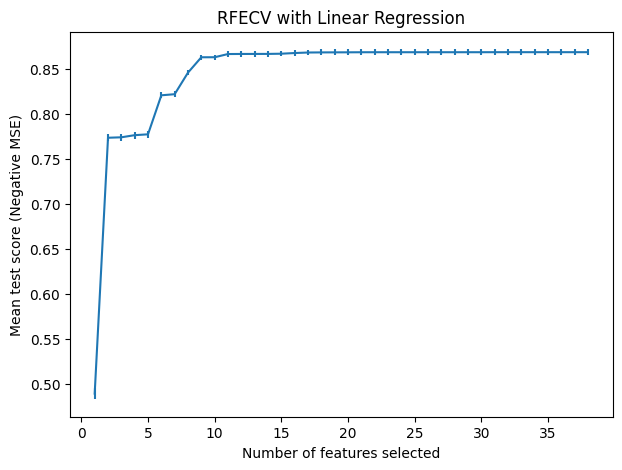


Running Forward SFS with Linear Regression...
SFS completed in 8.14 seconds.

--- Selected Features ---
RFECV selected 32 features.
SFS selected 2 features.

Common features selected by both (2):
['standard_model', 'mileage']


In [10]:
# 2. Automated Feature Selection 

# Data for feature selection
X_train_fs = X_train_final
y_train_fs = y_train

# Define Linear Regression for feature selection
model = LinearRegression()


# Recursive Feature Elimination (RFECV)
print("Running RFECV with Linear Regression...")
start_time = time.time()

# Use step=1 to evaluate dropping one feature at a time
rfe_selector = RFECV(model, step=1, cv=5, n_jobs=-1)
rfe_selector.fit(X_train_fs, y_train_fs)

print(f"RFECV completed in {time.time() - start_time:.2f} seconds.")
print(f"Optimal number of features: {rfe_selector.n_features_}")

# Plotting using error bars
n_scores = len(rfe_selector.cv_results_["mean_test_score"])
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(
    range(1, n_scores + 1),
    rfe_selector.cv_results_["mean_test_score"],
    yerr=rfe_selector.cv_results_["std_test_score"],
)
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Mean test score (Negative MSE)")
ax.set_title("RFECV with Linear Regression")
plt.show()

# Extract features
rfecv_features = rfe_selector.get_feature_names_out().tolist()



# Sequential Feature Selection (SFS)
print("\nRunning Forward SFS with Linear Regression...")
start_time = time.time()

# Initialise SFS
sfs_forward = SequentialFeatureSelector(
    model, 
    n_features_to_select='auto', 
    direction="forward", 
    tol=0.05, 
    cv=5, 
    n_jobs=-1
).fit(X_train_fs, y_train_fs)

print(f"SFS completed in {time.time() - start_time:.2f} seconds.")

# Extract features
sfs_features = sfs_forward.get_feature_names_out().tolist()


# 5. Review the Outputs
print("\n--- Selected Features ---")
print(f"RFECV selected {len(rfecv_features)} features.")
print(f"SFS selected {len(sfs_features)} features.")

# Find overlapping features
common_features = list(set(rfecv_features).intersection(set(sfs_features)))
print(f"\nCommon features selected by both ({len(common_features)}):")
print(common_features)

In [11]:
# 3. Random Forest and Gradient Boosted Trees 

# Use features selected by RFECV for model training
X_train_sub = X_train_final[rfecv_features]
X_val_sub = X_val_final[rfecv_features]

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20, None],
    'min_samples_leaf': [5, 10]
}

# Perform Grid Search for Random Forest
rf_grid = GridSearchCV(RandomForestRegressor(random_state=99), 
                        rf_param_grid, 
                        cv=3, 
                        n_jobs=-1, 
                        scoring='r2')

# Fit the model
rf_grid.fit(X_train_sub, y_train)

# Output best parameters and best estimator
print(f"Best RF Params: {rf_grid.best_params_}")
best_rf = rf_grid.best_estimator_

# Define parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Perform Grid Search for Gradient Boosting
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=99), 
                        gb_param_grid, 
                        cv=3, 
                        n_jobs=-1, 
                        scoring='r2')

# Fit the model
gb_grid.fit(X_train_sub, y_train)

# Output best parameters and best estimator
print(f"Best GB Params: {gb_grid.best_params_}")
best_gb = gb_grid.best_estimator_

Best RF Params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


--- Random Forest Performance ---
R2 Score: 0.9200
MAE (Price): £3174.67
--- Gradient Boosting Performance ---
R2 Score: 0.9206
MAE (Price): £3242.96


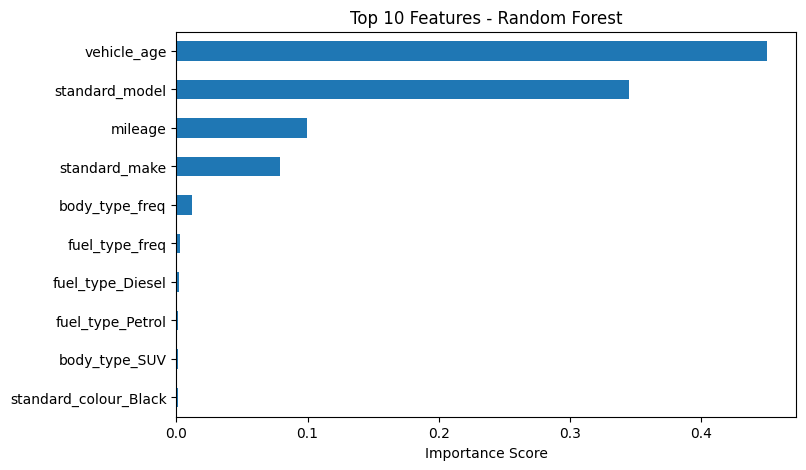

In [12]:
# Evaluate Rf and GB on validation set 
def evaluate_model(model, X, y_true, name):
    preds = model.predict(X)
    # Convert back from log to actual price for intuitive metrics
    y_true_actual = np.expm1(y_true)
    preds_actual = np.expm1(preds)
    
    print(f"--- {name} Performance ---")
    print(f"R2 Score: {r2_score(y_true, preds):.4f}")
    print(f"MAE (Price): £{mean_absolute_error(y_true_actual, preds_actual):.2f}")

# Evaluate the best models on the validation set
evaluate_model(best_rf, X_val_sub, y_val, "Random Forest")
evaluate_model(best_gb, X_val_sub, y_val, "Gradient Boosting")

# Visualise feature importance for Random Forest
def plot_importance(model, features, title):
    importances = pd.Series(model.feature_importances_, index=features)
    importances.sort_values().tail(10).plot(kind='barh', figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.show()

plot_importance(best_rf, rfecv_features, "Top 10 Features - Random Forest")

In [13]:
# 4. Ensemble of Ensembles using Stacking and Voting 

# Create a Voting Regressor ensemble of the best RF and GB models
voting_model = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb)
    ]
)

# Fit the voting regressor on the training data
voting_model.fit(X_train_sub, y_train)

# Evaluate the voting regressor on the validation set
stacking_model = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb)
    ],
    final_estimator=RidgeCV(), 
    cv=5
)


# Fit the stacking regressor on the training data
stacking_model.fit(X_train_sub, y_train)

# HistGradientBoosting since it is often faster and can handle missing values natively, making it a good candidate for comparison
hgb_model = HistGradientBoostingRegressor(random_state=99)
hgb_model.fit(X_train_sub, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [14]:
# Evaluate all Ensembles on the validation set 

# Models to evaluate
models = {
    "Voting": voting_model,
    "Stacking": stacking_model,
    "HistGB": hgb_model
}

# Evaluate and store results in a list of dictionaries for easy DataFrame creation
results = []
for name, model in models.items():
    preds = model.predict(X_val_sub)
    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    results.append({"Model": name, "R2": r2, "MAE": mae})

# Display as a formatted table
performance_df = pd.DataFrame(results)
print(performance_df)

      Model        R2          MAE
0    Voting  0.924616  3118.644678
1  Stacking  0.924383  3144.166082
2    HistGB  0.920034  3299.638300


Calculating Permutation Importance...


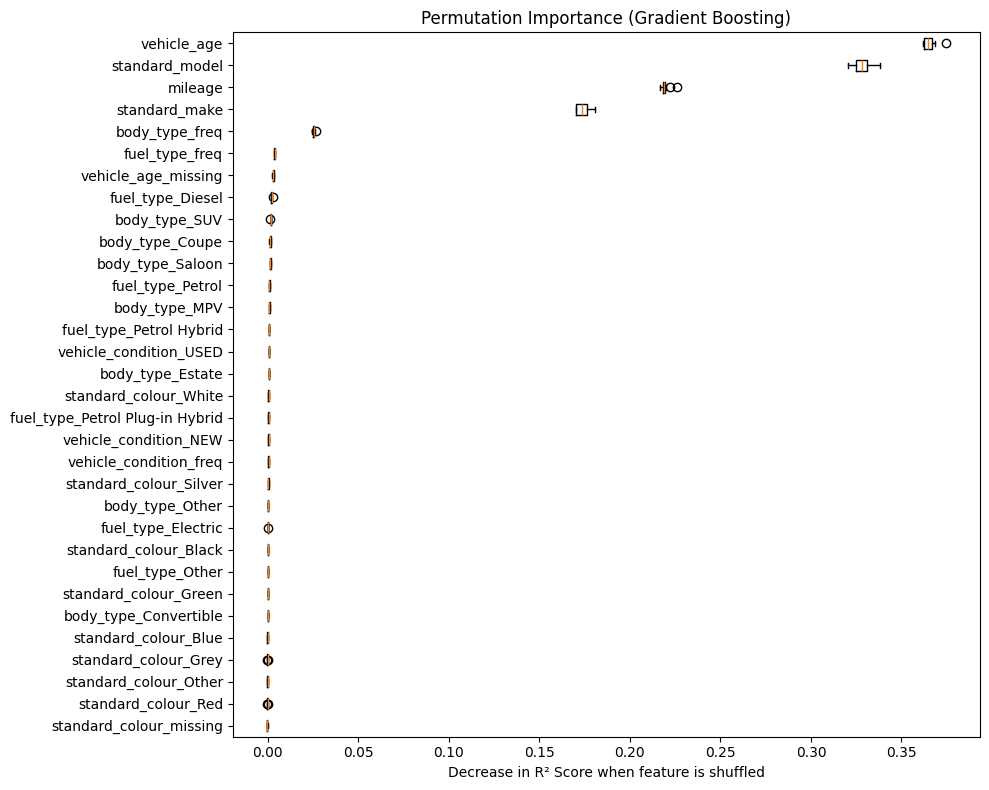

Calculating SHAP values for Global Importance...


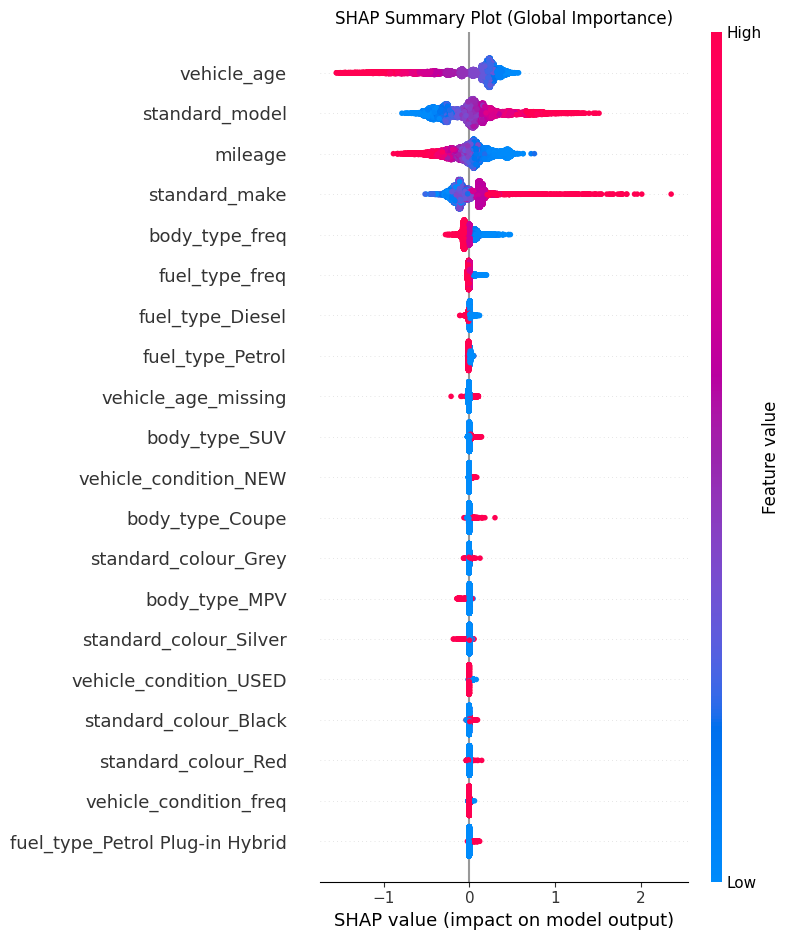

In [15]:
# 5. Feature Importance

# Define the model to explain
model_to_explain = best_gb 

# Permutation Importance
print("Calculating Permutation Importance...")
perm_result = permutation_importance(
    model_to_explain, X_val_sub, y_val, 
    n_repeats=10, random_state=99, n_jobs=-1
)

# Sort features by their mean importance
sorted_idx = perm_result.importances_mean.argsort()

# Plot Permutation Importance
plt.figure(figsize=(10, 8))
plt.boxplot(
    perm_result.importances[sorted_idx].T, 
    vert=False, 
    tick_labels=X_val_sub.columns[sorted_idx]
)
plt.title("Permutation Importance (Gradient Boosting)")
plt.xlabel("Decrease in R² Score when feature is shuffled")
plt.tight_layout()
plt.show()


# SHAP Values for Global Importance
print("Calculating SHAP values for Global Importance...")

# Initialise the SHAP explainer for the tree model
global_explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the entire validation set
shap_values = global_explainer.shap_values(X_val_sub)

# Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Global Importance)")
shap.summary_plot(shap_values, X_val_sub)
plt.show()

Generating SHAP Local Explanation (Waterfall Plot)...


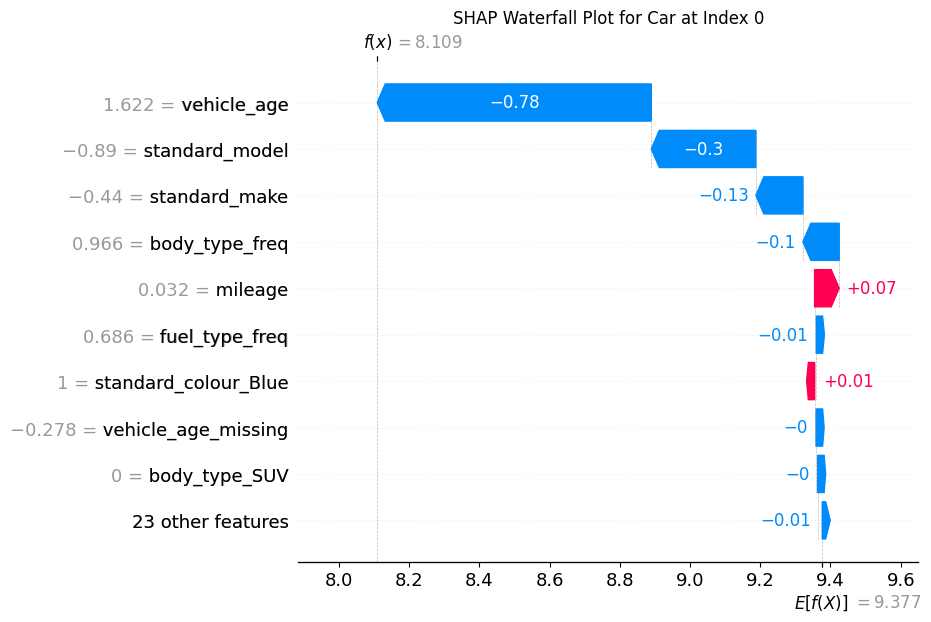

Generating Partial Dependence Plots (PDP)...


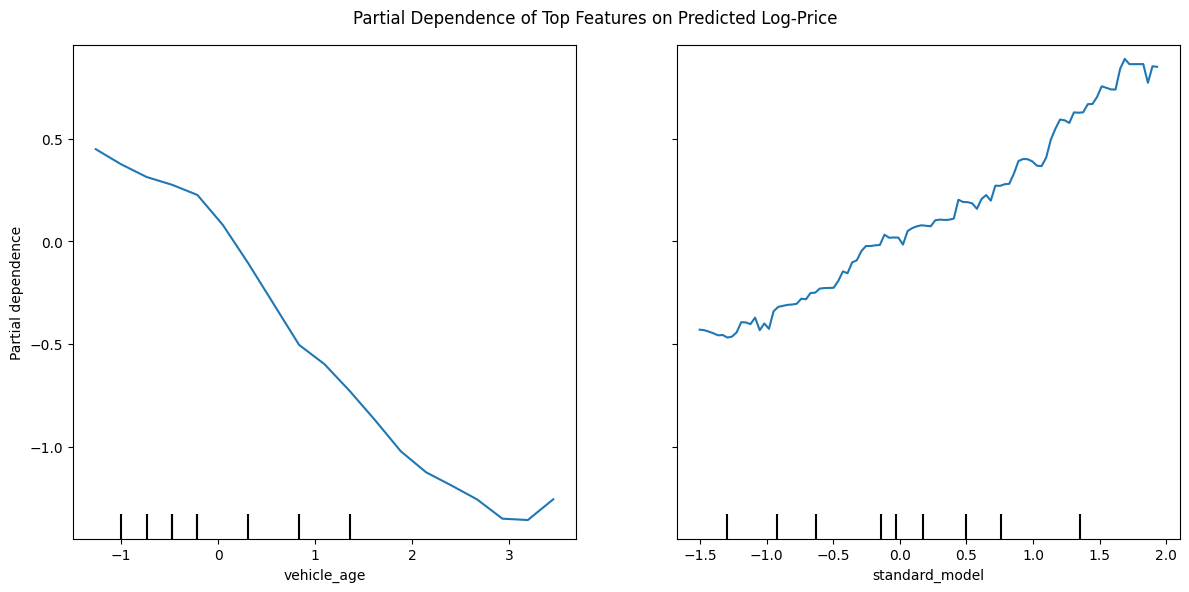

In [16]:
# 6. SHAP/PDP Model Explanation

# Define the model and data to explain
model_to_explain = best_gb 
X_explain = X_val_sub

# SHAP Local Explanation (Waterfall Plot)
print("Generating SHAP Local Explanation (Waterfall Plot)...")

# Initialise the SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the validation set (returns an Explanation object)
explanation = explainer(X_explain)

# Select a single observation to explain 
observation_index = 0 

# Generate the Waterfall Plot for this specific car
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Waterfall Plot for Car at Index {observation_index}")
shap.plots.waterfall(explanation[observation_index])
plt.show()


# Partial Dependence Plots (PDP)
print("Generating Partial Dependence Plots (PDP)...")

# Plot PDP for the top 2 most important features 
features_to_plot = ['vehicle_age', 'standard_model']

# Generate the Partial Dependence Plots
fig, ax = plt.subplots(figsize=(12, 6))
display = PartialDependenceDisplay.from_estimator(
    estimator=model_to_explain,
    X=X_explain,
    features=features_to_plot,
    feature_names=X_explain.columns,
    ax=ax,
    n_jobs=-1
)
plt.suptitle("Partial Dependence of Top Features on Predicted Log-Price")
plt.tight_layout()
plt.show()

Cumulative variance for first 10 components:
PC1: 0.210
PC2: 0.391
PC3: 0.519
PC4: 0.617
PC5: 0.706
PC6: 0.777
PC7: 0.843
PC8: 0.872
PC9: 0.896
PC10: 0.911


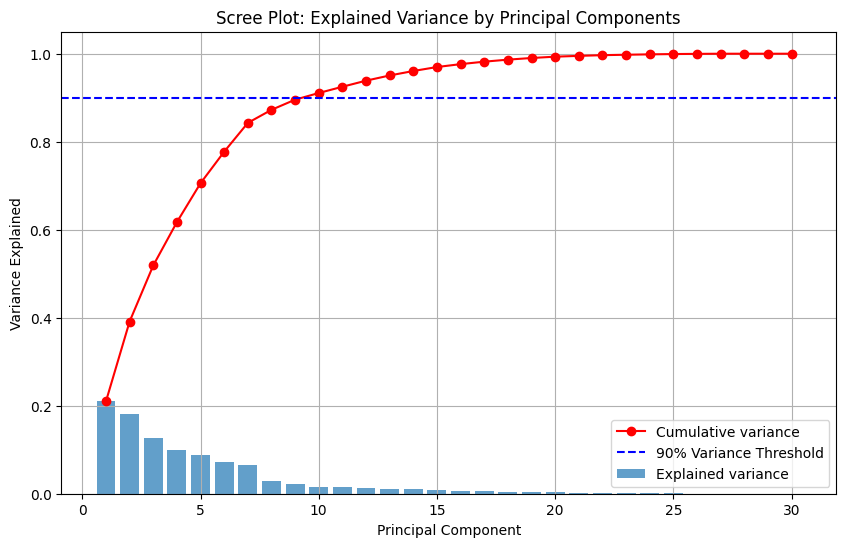

Original number of features: 38
Reduced number of features: 10


In [21]:
# 7. Linear Dimensionality Reduction with PCA

# Apply PCA to all features to analyse variance
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_train_final)

# Get explained variance and cumulative variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Print cumulative variance for the first 10 components 
print("Cumulative variance for first 10 components:")
for i, cv in enumerate(cumulative_variance[:10], 1):
    print(f"PC{i}: {cv:.3f}")

# Plotting the Scree Plot
plt.figure(figsize=(10, 6))
# Limit the number of components plotted for better visualisation
num_components_to_plot = min(30, len(explained_variance)) 

plt.bar(range(1, num_components_to_plot + 1), explained_variance[:num_components_to_plot], alpha=0.7, label='Explained variance')
plt.plot(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], 'ro-', label='Cumulative variance')

# Adding a threshold line
plt.axhline(y=0.90, color='b', linestyle='--', label='90% Variance Threshold')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.legend()
plt.grid(True)
plt.show()

# Optimal number of components based on the scree plot and cumulative variance
optimal_components = 10

# Apply PCA with the optimal number of components
pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_final)
X_test_pca = pca_optimal.transform(X_test_final) 

print(f"Original number of features: {X_train_final.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")

In [25]:
# 8. Non-Linear Dimensionality Reduction with t-SNE and Isomap

# Create subset data for t-SNE and Isomap due to computational intensity
np.random.seed(42)

# Taking a subset of 5000 rows for speed
subset_indices = np.random.choice(len(X_train_final), 5000, replace=False)

# Create subset data for t-SNE and Isomap
X_sub = X_train_final.iloc[subset_indices] 
y_sub = y_train.iloc[subset_indices]

# Apply Isomap 
print("Running Isomap...")
isomap = Isomap(n_components=2, n_neighbors=15)
X_iso = isomap.fit_transform(X_sub)

# Apply t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_sub)

Running Isomap...


/Users/ash/Library/CloudStorage/OneDrive-MMU/Desktop/MMU MY/Advanced Machine Learning/AT_AML/.venv/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/ash/Library/CloudStorage/OneDrive-MMU/Desktop/MMU MY/Advanced Machine Learning/AT_AML/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Running t-SNE...


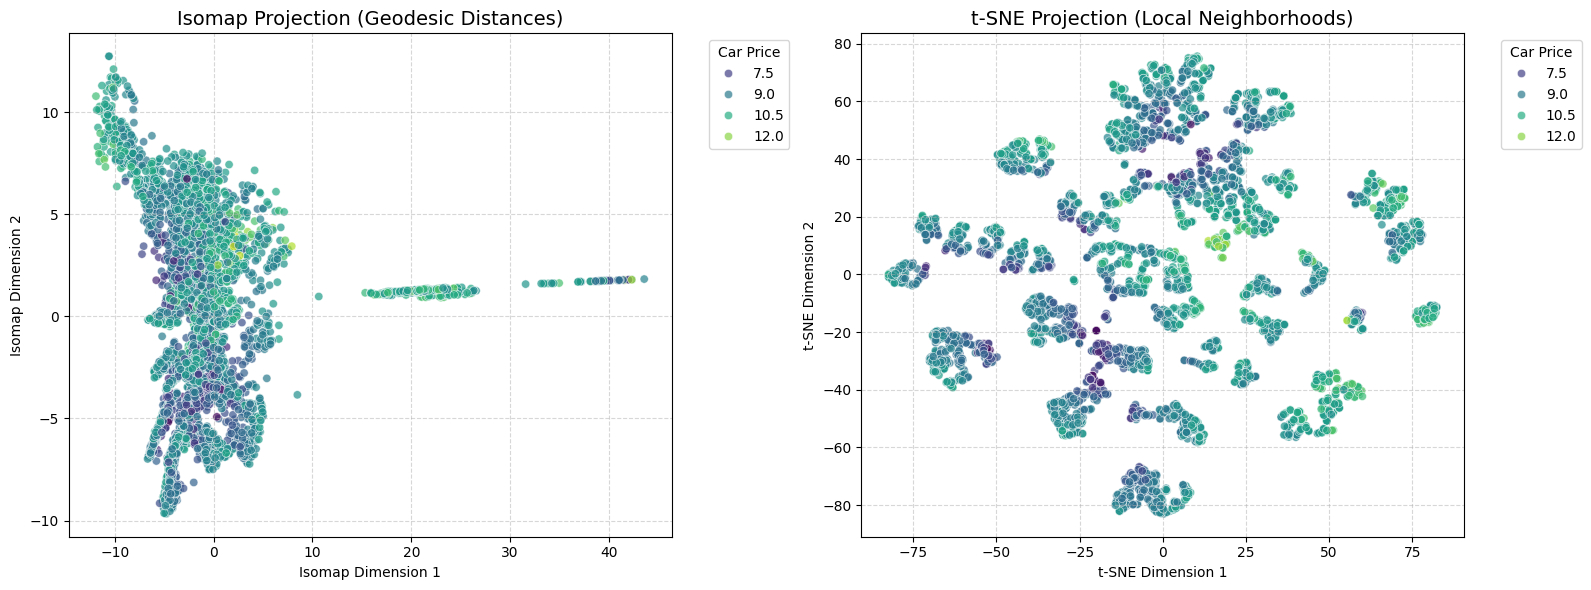

In [26]:
# Visualise the Isomap and t-SNE projections side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Isomap
sns.scatterplot(
    ax=axes[0],
    x=X_iso[:, 0], y=X_iso[:, 1],
    hue=y_sub,
    palette='viridis',
    alpha=0.7,
    edgecolor='w'
)
axes[0].set_title('Isomap Projection (Geodesic Distances)', fontsize=14)
axes[0].set_xlabel('Isomap Dimension 1')
axes[0].set_ylabel('Isomap Dimension 2')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Car Price', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot t-SNE 
sns.scatterplot(
    ax=axes[1],
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_sub,
    palette='viridis',
    alpha=0.7,
    edgecolor='w'
)
axes[1].set_title('t-SNE Projection (Local Neighborhoods)', fontsize=14)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Car Price', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 9. Polynomial Regression

# Create polynomial features for the 'vehicle_age' feature to capture non-linear relationships
X_train_age = X_train_final[['vehicle_age']].values
X_test_age = X_test_final[['vehicle_age']].values

# Randomly sample 1000 observations for visualisation to avoid overcrowding the plot
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_age), 1000, replace=False)
X_plot_scatter = X_train_age[sample_idx]
y_plot_scatter = y_train.iloc[sample_idx].values

# Create polynomial features (degree 2 or 3 is usually a good start to avoid overfitting)
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train_age)
X_test_poly = poly.transform(X_test_age)

print(f"Original shape: {X_train_age.shape}")
print(f"Polynomial features shape: {X_train_poly.shape}")

# Initialise and fit the Bayesian Regression model
bayesian_poly_model = BayesianRidge()
bayesian_poly_model.fit(X_train_poly, y_train)

# Evaluate on the test set
y_pred_test = bayesian_poly_model.predict(X_test_poly)
print(f"Test R2 Score: {r2_score(y_test, y_pred_test):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")

Original shape: (47802, 1)
Polynomial features shape: (47802, 4)
Test R2 Score: 0.435
Test RMSE: 0.644


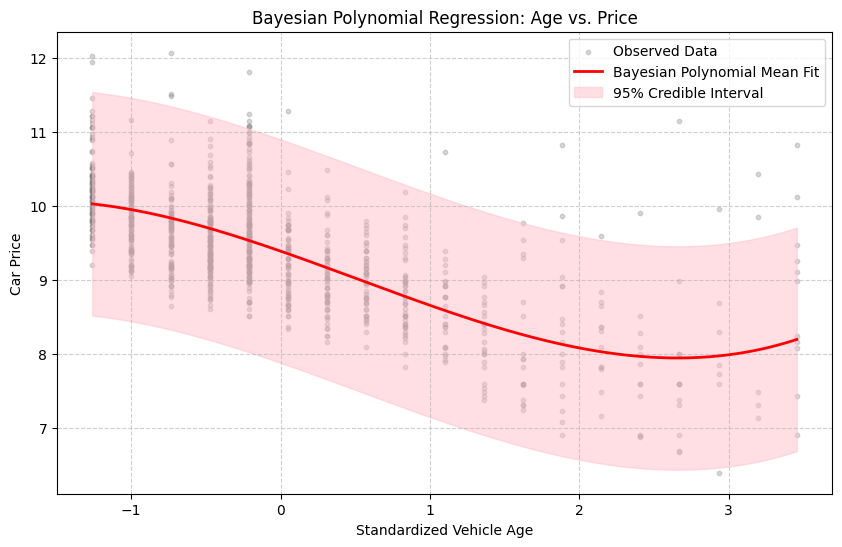

In [30]:
# Create a smooth line of X values for plotting the curve
X_line = np.linspace(X_train_age.min(), X_train_age.max(), 500).reshape(-1, 1)
X_line_poly = poly.transform(X_line)

# Predict the mean and the standard deviation (uncertainty)
y_mean, y_std = bayesian_poly_model.predict(X_line_poly, return_std=True)

plt.figure(figsize=(10, 6))

# Plot the actual data points (scattered)
plt.scatter(X_plot_scatter, y_plot_scatter, color='gray', alpha=0.3, label='Observed Data', s=10)

# Plot the Mean Regression Line
plt.plot(X_line, y_mean, color='red', linewidth=2, label='Bayesian Polynomial Mean Fit')

# Plot the Confidence Interval (Mean +/- 2 Standard Deviations)
plt.fill_between(X_line.ravel(), 
                 y_mean - 2 * y_std, 
                 y_mean + 2 * y_std, 
                 color='pink', alpha=0.5, label='95% Credible Interval')

plt.title('Bayesian Polynomial Regression: Age vs. Price')
plt.xlabel('Standardized Vehicle Age')
plt.ylabel('Car Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Calculating WCSS for Elbow Method...


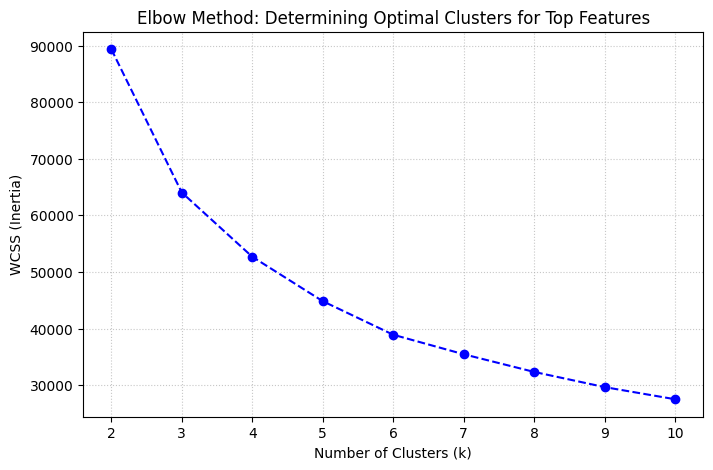

In [34]:
# 10. Clustering for feature engineering

# Using the top features identified by SHAP values in Task 6
features_for_clustering = ['vehicle_age', 'standard_model', 'standard_make']

# Extract these columns from your fully scaled and preprocessed datasets
X_cluster_train = X_train_final[features_for_clustering]
X_cluster_test = X_test_final[features_for_clustering]

# Determine the optimal number of clusters using the Elbow Method
wcss = []
k_range = range(2, 11) 

# Calculate WCSS for each k in the range
print("Calculating WCSS for Elbow Method...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_train)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Determining Optimal Clusters for Top Features')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [35]:
# 10. Based on the Elbow Plot, choose the optimal number of clusters (k) and fit K-Means to create a new feature representing cluster membership. Add this new feature back to your training and test sets for use in model training.

# Set this to the number you identified from  Elbow Plot
optimal_k = 4 

# Initialise the final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit on the training data and get the cluster labels
train_cluster_labels = kmeans_final.fit_predict(X_cluster_train)

# Transform the test data (map test points to the existing training clusters)
test_cluster_labels = kmeans_final.predict(X_cluster_test)

# Add the labels back as a brand new feature
X_train_final['shap_cluster_group'] = train_cluster_labels
X_test_final['shap_cluster_group'] = test_cluster_labels

print(f"Successfully added 'shap_cluster_group' ({optimal_k} clusters) to train and test sets.")

Successfully added 'shap_cluster_group' (4 clusters) to train and test sets.


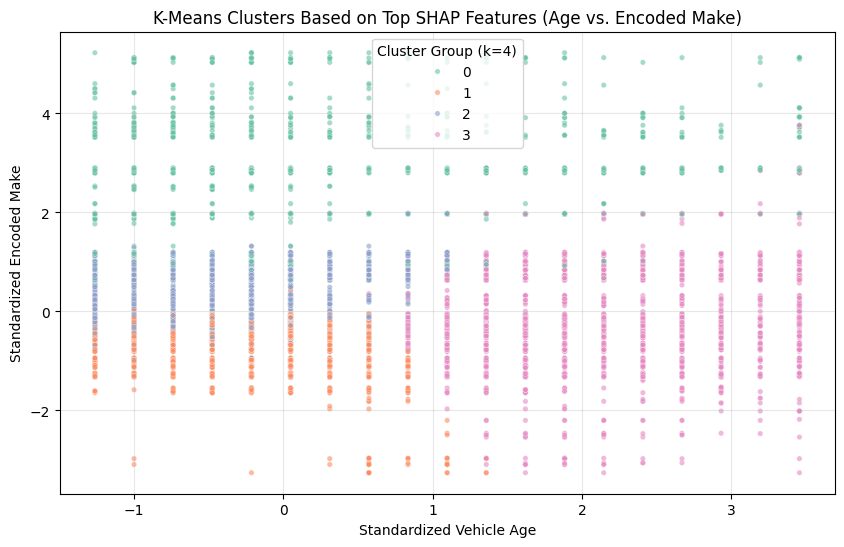

In [37]:
# Visualise the clusters in a 2D scatter plot using the top two features (e.g., 'vehicle_age' and 'standard_make') to see how the clusters are formed based on these important features.

plt.figure(figsize=(10, 6))

# Plotting Age vs. the numerically encoded 'Make', colored by cluster
sns.scatterplot(
    x=X_cluster_train['vehicle_age'], 
    y=X_cluster_train['standard_make'], 
    hue=train_cluster_labels, 
    palette='Set2', 
    alpha=0.6,
    s=15 # small dot size
)

plt.title('K-Means Clusters Based on Top SHAP Features (Age vs. Encoded Make)')
plt.xlabel('Standardized Vehicle Age')
plt.ylabel('Standardized Encoded Make')
plt.legend(title=f'Cluster Group (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.show()